In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import warnings
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [3]:
df = pd.read_csv('cardekho_imputated.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

## DATA CLEANING

In [6]:
df.drop(columns=['car_name','brand','Unnamed: 0'],axis=1,inplace=True)

In [7]:
num_features = [feature for feature in df.columns if df[feature].dtypes != 'object']
cat_features = [feature for feature in df.columns if df[feature].dtypes == 'object']
print(num_features)
print(cat_features)

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
['model', 'seller_type', 'fuel_type', 'transmission_type']


## FEATURE ENCODING AND SCALING

In [8]:
X = df.drop(columns=['selling_price'],axis=1)
y = df['selling_price']

le = LabelEncoder()
X['model'] = le.fit_transform(X['model'])

In [9]:
nume_featires = X.select_dtypes(exclude=['object']).columns
ohe_columns = ['seller_type','fuel_type','transmission_type']

num_transofrmer = StandardScaler()
ohe_transformer = OneHotEncoder(handle_unknown='ignore',drop='first')

preprocessor = ColumnTransformer(
    [
        ('StandardScaler',num_transofrmer,nume_featires),
        ('OneHotEncoder',ohe_transformer,ohe_columns)
    ],remainder='passthrough'
)

In [10]:
X = preprocessor.fit_transform(X)
X

array([[-1.51971354e+00,  9.83561835e-01,  1.24733473e+00, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [-2.25693398e-01, -3.43933310e-01, -6.90016231e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 1.53637659e+00,  1.64730941e+00,  8.49241548e-02, ...,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       ...,
       [ 4.07550503e-01, -1.20595237e-02,  2.20538722e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 1.42624721e+00, -3.43933310e-01,  7.25418502e+01, ...,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-1.02413136e+00, -1.33955467e+00, -8.25630799e-01, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00]])

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## MODEL TRAINING

In [12]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    r2 = r2_score(true,predicted)
    return mae,mse,r2

In [13]:
models = {
    "Random Forest":RandomForestRegressor(),
    "KNN":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "Logistic Regression":LogisticRegression(),
    "Xgboost Regressor":XGBRegressor()
}
l=[]
for model_name,model_instance in models.items():
    model_instance.fit(X_train,y_train)
    y_train_pred = model_instance.predict(X_train)
    y_pred = model_instance.predict(X_test)
    model_train_mae,model_train_mse,model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_r2 = evaluate_model(y_test,y_pred)
    print(model_name)
    print('Model training Performance')
    print("Root mean squared error: ",model_train_mse)
    print("Mean absolute error: ",model_train_mae)
    print("R2 score: ",model_train_r2)
    print('Model testing Performance')
    print("Root mean squared error: ",model_test_mse)
    print("Mean absolute error: ",model_test_mae)
    print("R2 score: ",model_test_r2)
    print('------------------------------------')
    l.append([model_train_r2,model_test_r2])

Random Forest
Model training Performance
Root mean squared error:  17392556170.63549
Mean absolute error:  39761.625989186745
R2 score:  0.9785551045760812
Model testing Performance
Root mean squared error:  51384114722.06146
Mean absolute error:  101924.50360626147
R2 score:  0.9317410232664128
------------------------------------
KNN
Model training Performance
Root mean squared error:  106198752384.81505
Mean absolute error:  91396.54445165477
R2 score:  0.869057709706405
Model testing Performance
Root mean squared error:  64079155016.42069
Mean absolute error:  112578.24359390205
R2 score:  0.9148768529917701
------------------------------------
Decision Tree
Model training Performance
Root mean squared error:  432524990.53644824
Mean absolute error:  5164.819922128488
R2 score:  0.9994666998284044
Model testing Performance
Root mean squared error:  95560064780.62944
Mean absolute error:  125364.05827657043
R2 score:  0.8730574171842153
------------------------------------
Lasso
Mod

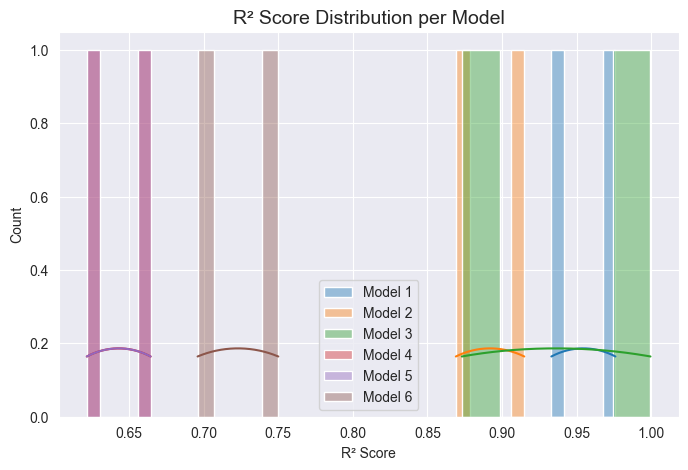

In [14]:
plt.figure(figsize=(8,5))
for i, scores in enumerate(l):
    sns.histplot(scores, kde=True, label=f"Model {i+1}", bins=5, alpha=0.4)

plt.title("R² Score Distribution per Model", fontsize=14)
plt.xlabel("R² Score")
plt.ylabel("Count")
plt.legend()
plt.show()

In [18]:
params = {
    'n_estimators': [1,10,50,100,1000],
    'max_depth':[None,1,2,3,4,5],
    'min_samples_split':[2,5,10,15,20],
    'min_samples_leaf':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [19]:
gridcv = GridSearchCV(estimator=RandomForestRegressor(),param_grid=params,cv=5,n_jobs=-1)
randcv = RandomizedSearchCV(estimator=RandomForestRegressor(),param_distributions=params,cv=5,n_jobs=-1)
gridcv.fit(X_train,y_train)
randcv.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [None, 1, 2, 3, 4, 5],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4, 5],
                                        'min_samples_split': [2, 5, 10, 15, 20],
                                        'n_estimators': [1, 10, 50, 100, 1000]})

In [20]:
gridcv.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [21]:
randcv.best_params_

{'n_estimators': 50,
 'min_samples_split': 20,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': None}

In [22]:
y_pred = gridcv.predict(X_test)
print('gridcv:')
print(r2_score(y_test,y_pred))

gridcv:
0.9417460345080578


In [23]:
y_pred = randcv.predict(X_test)
print('randcv:')
print(r2_score(y_test,y_pred))

randcv:
0.904984923150703
